<a href="https://colab.research.google.com/github/NdopnnoabasiJames/Machine-Learning-Models/blob/main/PCA_vs_t_SNE_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing PCA and t-SNE for High-Dimensional Data Visualization

In this notebook, I compare Principal Component Analysis (PCA) and t-SNE as dimensionality reduction techniques for visualizing high-dimensional data.

I used the Wine dataset and projected it down to two dimensions with both methods, then looked at how each one preserves structure, similarity, and class separation. The goal is to get a better sense of when to use PCA versus t-SNE in actual machine learning work.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## Load and Prepare Data

In [2]:
wine = load_wine()
X = wine.data
y = wine.target

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Since both PCA and t-SNE are sensitive to feature scale, the data is standardized to ensure all features contribute equally to the distance calculations.

## PCA Projection (2 Components)

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Class'] = y

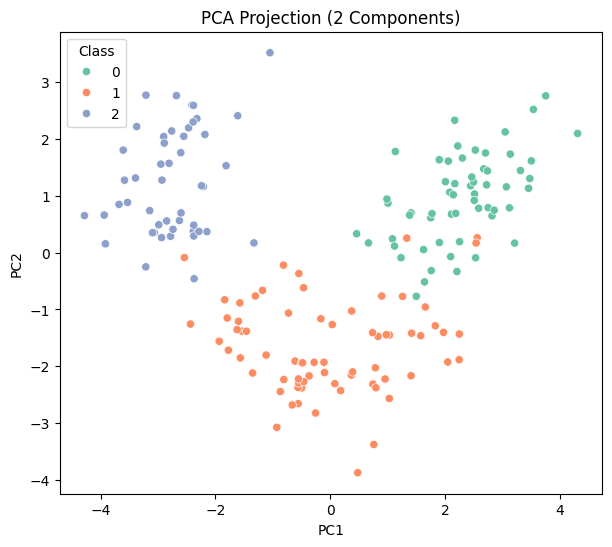

In [5]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Class',
    palette='Set2',
    data=pca_df
)
plt.title('PCA Projection (2 Components)')
plt.show()

## t-SNE Projection (2 Components)

In [6]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
tsne_df['Class'] = y

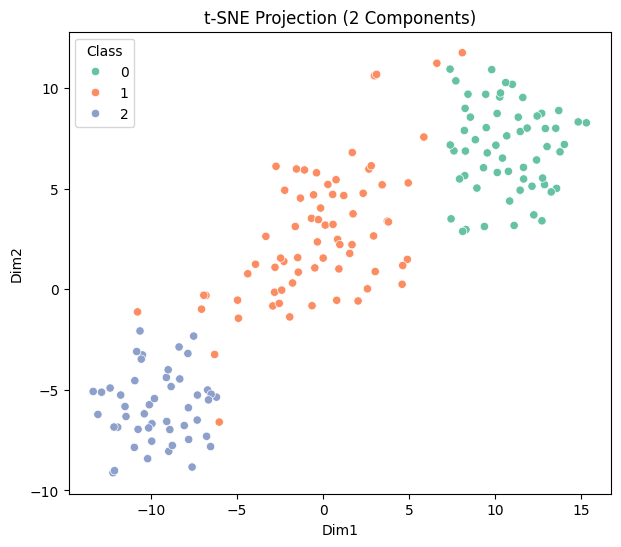

In [7]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    x='Dim1',
    y='Dim2',
    hue='Class',
    palette='Set2',
    data=tsne_df
)
plt.title('t-SNE Projection (2 Components)')
plt.show()

PCA and t-SNE both reduce dimensionality, but they serve different purposes. PCA is a linear technique that preserves global variance and is suitable for preprocessing and interpretation. In contrast, t-SNE is a non-linear method designed purely for visualization, emphasizing local neighborhood relationships rather than overall structure.

# Conclusion


In this notebook, I compared PCA and t-SNE for reducing dimensions and visualizing the Wine dataset. I scaled the features first to make sure the comparison was fair.

PCA gave me a linear projection that kept the overall structure of the data intact and showed meaningful separation between wine classes based on variance. There was some overlap, but PCA created a stable and easy-to-interpret view of the data that reflects its overall shape. It's good for preprocessing and feeding into other models.

t-SNE focused more on keeping nearby points close together and created tighter, more separated clusters in two dimensions. This made the patterns much easier to see, but it came with trade-offs. You lose the ability to interpret global distances, and the results can change if you run it again.

The takeaway is that PCA and t-SNE do different things and both have their place. PCA is better for reducing dimensions and compressing features, while t-SNE is great for exploring and visualizing local structure in high-dimensional data.